In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [2]:
# Set plot style
sns.set_theme(style="whitegrid")

In [5]:
# Load dataset
df = pd.read_csv('BBC News Train.csv')

#preprocessing

In [7]:
print("--- INITIAL DATA INSPECTION ---")
print(f"Initial row count: {len(df)}")
print(f"Missing values:\n{df.isna().sum()}\n")

# Drop null values if any exist
df.dropna(subset=['Text', 'Category'], inplace=True)

# Drop exact duplicate text rows
df.drop_duplicates(subset=['Text'], inplace=True)
print(f"Row count after removing duplicates: {len(df)}")

--- INITIAL DATA INSPECTION ---
Initial row count: 1490
Missing values:
ArticleId    0
Text         0
Category     0
dtype: int64

Row count after removing duplicates: 1440


# . TEXT PREPROCESSING FUNCTION

In [8]:
def clean_text(text):
    text = str(text).lower()                         # Lowercase text
    text = re.sub(r'[^a-z\s]', '', text)             # Remove punctuation and digits
    text = re.sub(r'\s+', ' ', text).strip()         # Remove extra whitespace
    return text

# Apply text cleaning
df['cleaned_text'] = df['Text'].apply(clean_text)

#. OUTLIER DETECTION & EDA


In [9]:

# =====================================================================
# Calculate word counts for EDA and outlier checking
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))    #x.split which  separate clean string into list of words and count them

print("\n--- WORD COUNT STATISTICS ---")
print(df['word_count'].describe())

# Remove extreme length outliers (e.g., empty/unusually short articles < 10 words)
df = df[df['word_count'] >= 10].copy()
print(f"Row count after dropping word count outliers: {len(df)}")


--- WORD COUNT STATISTICS ---
count    1440.000000
mean      377.189583
std       208.654239
min        89.000000
25%       245.750000
50%       331.000000
75%       461.000000
max      3266.000000
Name: word_count, dtype: float64
Row count after dropping word count outliers: 1440


/tmp/ipykernel_579/2837018131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', ax=axes[0], palette='viridis')
/tmp/ipykernel_579/2837018131.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='word_count', ax=axes[1], palette='viridis')


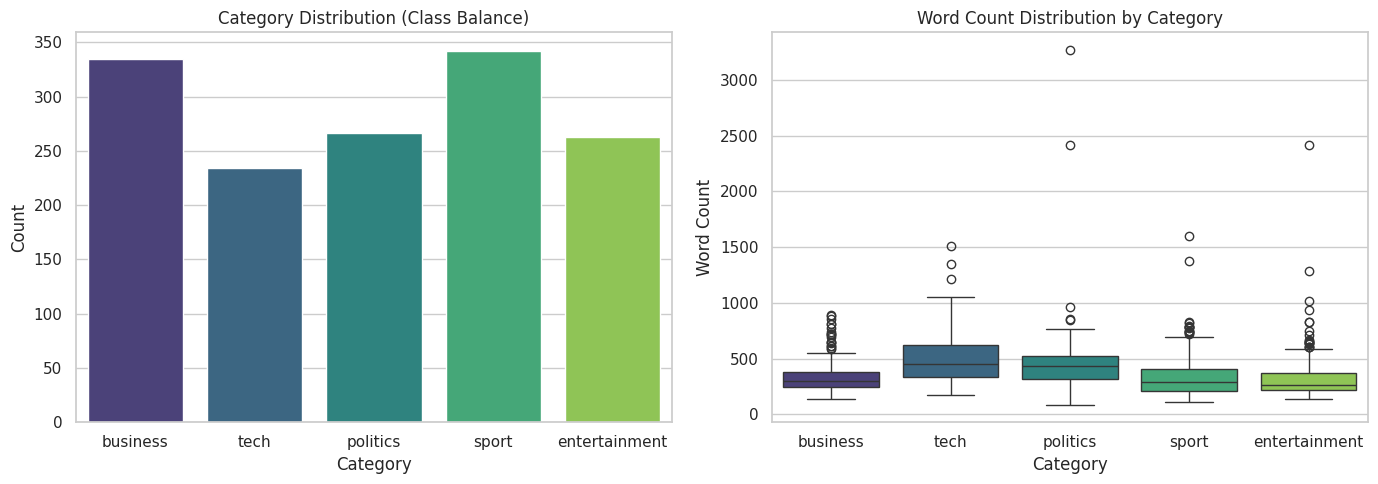

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Category Distribution
sns.countplot(data=df, x='Category', ax=axes[0], palette='viridis')
axes[0].set_title("Category Distribution (Class Balance)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")

# Plot 2: Word Count Distribution per Category
sns.boxplot(data=df, x='Category', y='word_count', ax=axes[1], palette='viridis')
axes[1].set_title("Word Count Distribution by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.show()

#. TRAIN-TEST SPLIT

In [11]:

X = df['cleaned_text']
y = df['Category']

# Stratified split to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Training set size: 1152
Testing set size: 288


#. FEATURE ENGINEERING (TF-IDF VECTORIZATION)

In [12]:
# Convert raw text to TF-IDF matrix with L2 normalization
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),
    norm='l2'
)

# Fit on training data ONLY; transform both train and test sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")


TF-IDF Matrix Shape (Train): (1152, 5000)


#MODEL TRAINING (MULTINOMIAL LOGISTIC REGRESSION)

In [13]:
# Standard Multinomial Softmax Logistic Regression Baseline
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

#EVALUATION


TEST ACCURACY: 0.9618

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     business       0.94      0.97      0.96        67
entertainment       1.00      0.98      0.99        53
     politics       0.98      0.96      0.97        53
        sport       0.93      1.00      0.96        68
         tech       0.98      0.87      0.92        47

     accuracy                           0.96       288
    macro avg       0.97      0.96      0.96       288
 weighted avg       0.96      0.96      0.96       288



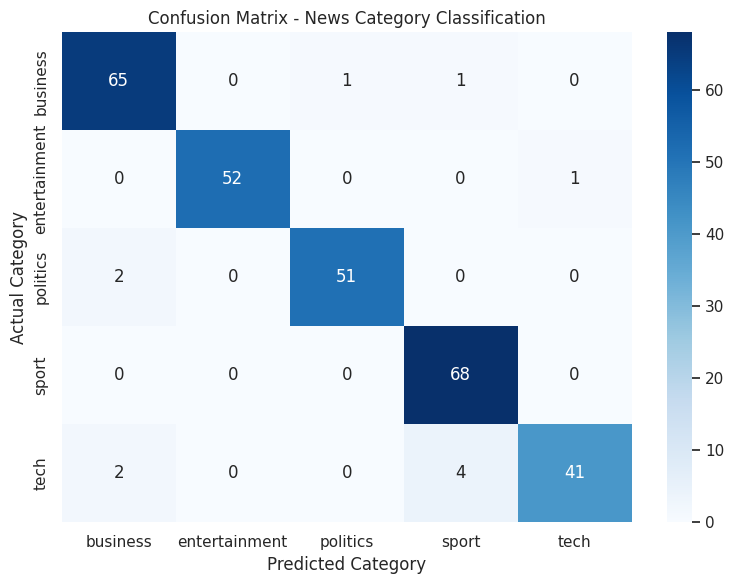

In [14]:
# Predictions
y_pred = model.predict(X_test_tfidf)

# Print overall performance metrics
print("\n" + "="*50)
print(f"TEST ACCURACY: {accuracy_score(y_test, y_pred):.4f}")
print("="*50)
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title("Confusion Matrix - News Category Classification")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.tight_layout()
plt.show()

In [16]:
# Predict on both training and testing datasets
y_train_pred = model.predict(X_train_tfidf)
y_test_pred = model.predict(X_test_tfidf)

# Calculate accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Display performance and variance gap
print("=" * 40)
print(f"Training Accuracy : {train_acc * 100:.2f}%")
print(f"Testing Accuracy  : {test_acc * 100:.2f}%")
print(f"Variance Gap      : {(train_acc - test_acc) * 100:.2f}%")
print("=" * 40)

Training Accuracy : 99.74%
Testing Accuracy  : 96.18%
Variance Gap      : 3.56%


# test on testing data

In [17]:
# 1. Load test data
df_test = pd.read_csv('BBC News Test.csv')

# 2. Fill missing text if any exist
df_test['Text'] = df_test['Text'].fillna('')

# 3. Apply the same cleaning function used on training data
df_test['cleaned_text'] = df_test['Text'].apply(clean_text)

# 4. Transform using the existing fitted TF-IDF vectorizer
# CRITICAL: Use .transform(), NEVER .fit_transform() here to avoid data leakage
X_unseen_tfidf = tfidf.transform(df_test['cleaned_text'])

print(f"Unseen Test Matrix Shape: {X_unseen_tfidf.shape}")

Unseen Test Matrix Shape: (735, 5000)


In [18]:
# 1. Predict categories using the trained Logistic Regression model
test_predictions = model.predict(X_unseen_tfidf)

# 2. Create the submission DataFrame matching Kaggle's required format
submission = pd.DataFrame({
    'ArticleId': df_test['ArticleId'],
    'Category': test_predictions
})

# 3. Save predictions to a CSV file
submission.to_csv('submission.csv', index=False)

# 4. Preview the first few predicted rows
print("Predictions generated and saved to 'submission.csv' successfully!\n")
print(submission.head(10))

Predictions generated and saved to 'submission.csv' successfully!

   ArticleId       Category
0       1018          sport
1       1319           tech
2       1138          sport
3        459       business
4       1020          sport
5         51          sport
6       2025       politics
7       1479       politics
8         27  entertainment
9        397       business


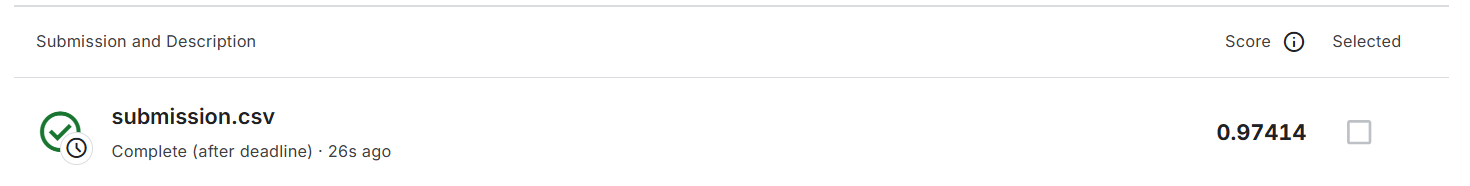

let me sammurize every thing in this model a baseline of nlp as we use a amll part of it in this supervised model is first we take dataset and clean it in perspectiv of duplicates and missing values then we clean our text like remove special character and spaces then we do outlier detection as we remove space we use x.split which separate clean string into list of words and count them this give stastistic that our dataset which article gas min word mean median and so on to remove outlier we remove article with less then 10 words then for long article we do not remove them as l2 will standarize them then we plot boxes to see word count per article and check which category appear more oftenly or rarely then we split our dataset then we use tf idf which remove filler word it will cretae max feature or cilumn of unique words 5000 or our desire then if we have to choose unigram or bigram words like interest and rate then what tfidf do is for every column it check unique words in front of the article if any article uses those point then probability calculated by tf and idf which is then standarize by l2 which what do is square all tf idf value sum them then square root then divide every row by that score but in our program we do not use l2



Pipeline Summary VerificationData Hygiene:

- Dropping missing values (isna()) and identical raw articles (drop_duplicates()) first prevents data leakage and wasted compute. (100% Correct)

- Text Normalization: Converting to lower case and using regex ([^a-z\s]) strips out punctuation, special characters, and numbers so identical words map to the same token. (100% Correct)Length
- Outliers: Using x.split() to calculate word counts and inspecting summary statistics (describe()) to drop corrupted articles (<10 words). (100% Correct)

- EDA & Split: Checking category balance via count plots, inspecting length distributions across categories using box plots, and splitting with stratify=y. (100% Correct)

- TF-IDF Mechanics: Removing stop words, building a 5,000-feature vocabulary matrix, capturing unigrams/bigrams, and calculating $TF \times IDF$ weights for every document. (100% Correct)

- L2 Normalization: Squaring row scores, taking the square root of their sum, and dividing each cell by that magnitude. Because this was enabled in our TfidfVectorizer, long articles (like the 3,266-word outlier) were automatically scaled down, so we didn't need to manually trim them. (100% Correct)